In [17]:
import sys
import os
import numpy as np
import healpy as hp

# Fix paths so importlib can find 'echosims' package layout
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from echosims.utils import EchoInstrument

class Noise(EchoInstrument):

    def __init__(self):
        super().__init__()
        self.EchoInstrument = EchoInstrument
        pass

    def TQU(self, band, nside):

        npix = hp.nside2npix(nside)
        pix_area = hp.nside2pixarea(nside, degrees = True) # Unit - Degrees^2
        pix_len = np.sqrt(pix_area) # Unit - Degrees

        # Temperature Noise Map
        sigma_T = self.get_temperature_sensitivity(band)/60 # Unit conversion from muKarmin to muKdegree
        std_dev_T = sigma_T/pix_len
        T_noise = np.random.normal(0, std_dev_T, npix)

        # Q Noise Map
        sigma_Q = self.get_polarization_sensitivity(band)/60 # Unit conversion from muKarmin to muKdegree
        std_dev_Q = sigma_Q/pix_len
        Q_noise = np.random.normal(0, std_dev_Q, npix)

        # U Noise Map
        sigma_U = self.get_polarization_sensitivity(band)/60 # Unit conversion from muKarmin to muKdegree
        std_dev_U = sigma_U/pix_len
        U_noise = np.random.normal(0, std_dev_U, npix)

        return (T_noise, Q_noise, U_noise)
        
noise = Noise()
noise = noise.TQU(130, 128)
print(noise)

(array([-0.0113574 ,  0.0168911 ,  0.19274531, ...,  0.11922275,
        0.00252692, -0.11858909], shape=(196608,)), array([ 0.12910933,  0.01579963,  0.06639657, ..., -0.0556959 ,
       -0.05724775, -0.08804399], shape=(196608,)), array([-0.02277409, -0.01705325,  0.05596649, ...,  0.15570271,
       -0.02280889,  0.10161833], shape=(196608,)))


In [ ]:
import matplotlib.pyplot as plt


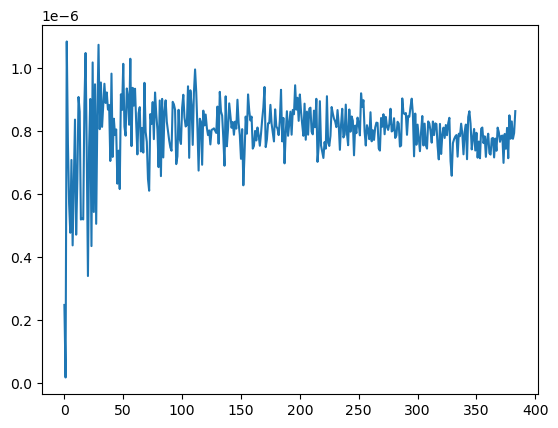

In [18]:
y = hp.anafast(noise[2])
x = np.arange(len(y))
plt.plot(x,y)